# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

## Sumber Dataset

Dataset diperoleh dari repository proyek Credit Scoring yang digunakan dalam pembelajaran MLOps:

https://github.com/TenKai231/Belajar_MLops-

Dataset telah melalui preprocessing dan reduksi dimensi (PCA) sebelum digunakan pada eksperimen ini.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
# 2. Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
df = pd.read_csv("../dataset_raw/train_pca.csv")
df.head()

,Age,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,pc1_1,pc1_2,pc1_3,pc1_4,pc1_5,pc2_1,pc2_2,Credit_Score
0,0.690476,2,2,0,0.216025,0.335070,0.056151,0.047829,0.146897,-0.041306,0.042562,2
1,0.190476,1,1,0,-0.319038,0.112770,0.227198,0.055694,0.117256,0.278801,0.108811,0
2,0.428571,1,1,3,-0.419239,0.069822,0.232682,-0.110793,0.251450,-0.200276,0.056651,0
3,0.476190,1,0,0,-0.257237,-0.237483,0.376886,-0.068433,0.012728,-0.168980,0.037451,0
4,0.452381,1,1,5,-0.502552,0.073821,0.226193,-0.284319,-0.015748,-0.198335,-0.034793,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
#Type your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50808 entries, 0 to 50807
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    50808 non-null  float64
 1   Credit_Mix             50808 non-null  int64  
 2   Payment_of_Min_Amount  50808 non-null  int64  
 3   Payment_Behaviour      50808 non-null  int64  
 4   pc1_1                  50808 non-null  float64
 5   pc1_2                  50808 non-null  float64
 6   pc1_3                  50808 non-null  float64
 7   pc1_4                  50808 non-null  float64
 8   pc1_5                  50808 non-null  float64
 9   pc2_1                  50808 non-null  float64
 10  pc2_2                  50808 non-null  float64
 11  Credit_Score           50808 non-null  int64  
dtypes: float64(8), int64(4)
memory usage: 4.7 MB


In [6]:
df.describe()

,Age,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,pc1_1,pc1_2,pc1_3,pc1_4,pc1_5,pc2_1,pc2_2,Credit_Score
count,50808.000000,50808.000000,50808.000000,50808.000000,5.080800e+04,5.080800e+04,5.080800e+04,5.080800e+04,5.080800e+04,5.080800e+04,5.080800e+04,50808.000000
mean,0.468683,1.515608,1.332389,2.958668,8.181143e-17,2.258555e-17,-4.090571e-17,-1.846001e-17,1.061101e-17,4.915678e-17,-1.185217e-17,1.000000
std,0.258129,1.009663,0.685671,1.976027,5.687249e-01,2.046556e-01,1.705790e-01,1.646248e-01,1.531693e-01,2.553639e-01,1.215272e-01,0.816505
min,0.000000,0.000000,0.000000,0.000000,-9.360719e-01,-6.738205e-01,-6.204886e-01,-6.176263e-01,-5.724390e-01,-3.136296e-01,-7.238451e-01,0.000000
25%,0.261905,1.000000,1.000000,1.000000,-4.817875e-01,-1.436896e-01,-1.179284e-01,-1.120678e-01,-1.029299e-01,-2.043387e-01,-4.335699e-02,0.000000
50%,0.452381,1.000000,1.000000,3.000000,-1.769058e-01,1.213647e-02,7.199985e-04,-2.277561e-04,-2.779831e-04,-8.949644e-02,1.908437e-02,1.000000
75%,0.666667,2.000000,2.000000,5.000000,5.157793e-01,1.492467e-01,1.188504e-01,1.115222e-01,1.025901e-01,1.367666e-01,5.955841e-02,2.000000
max,1.000000,3.000000,2.000000,6.000000,1.416377e+00,6.245706e-01,6.312982e-01,6.033564e-01,6.464555e-01,1.104966e+00,4.862872e-01,2.000000


In [7]:
df.isnull().sum()

Age                      0
Credit_Mix               0
Payment_of_Min_Amount    0
Payment_Behaviour        0
pc1_1                    0
pc1_2                    0
pc1_3                    0
pc1_4                    0
pc1_5                    0
pc2_1                    0
pc2_2                    0
Credit_Score             0
dtype: int64

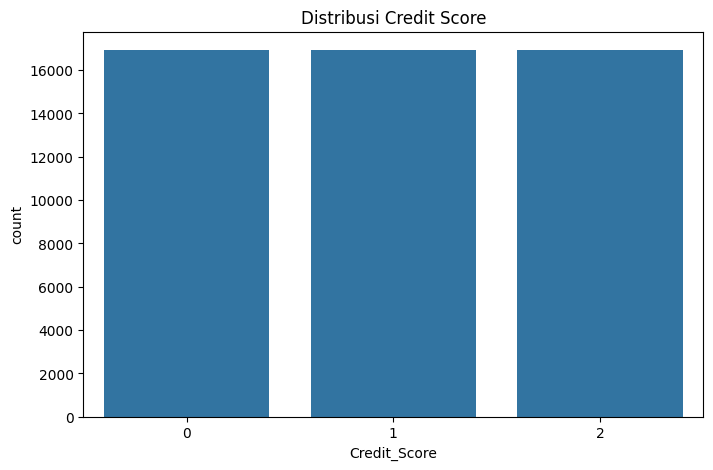

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Credit_Score")
plt.title("Distribusi Credit Score")
plt.show()

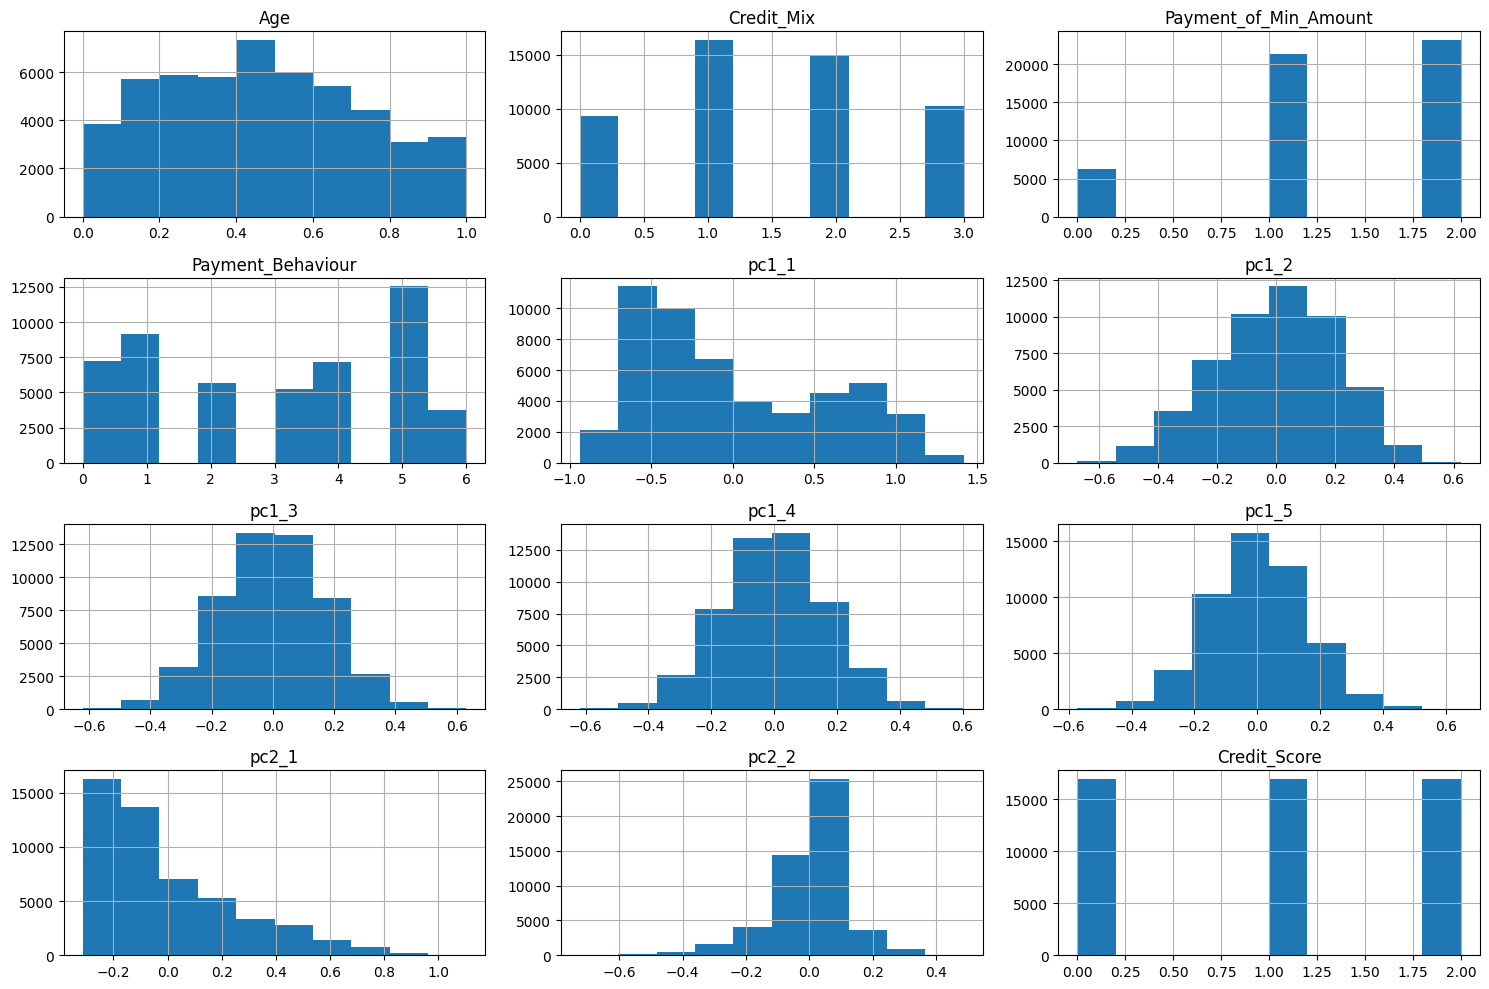

In [9]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

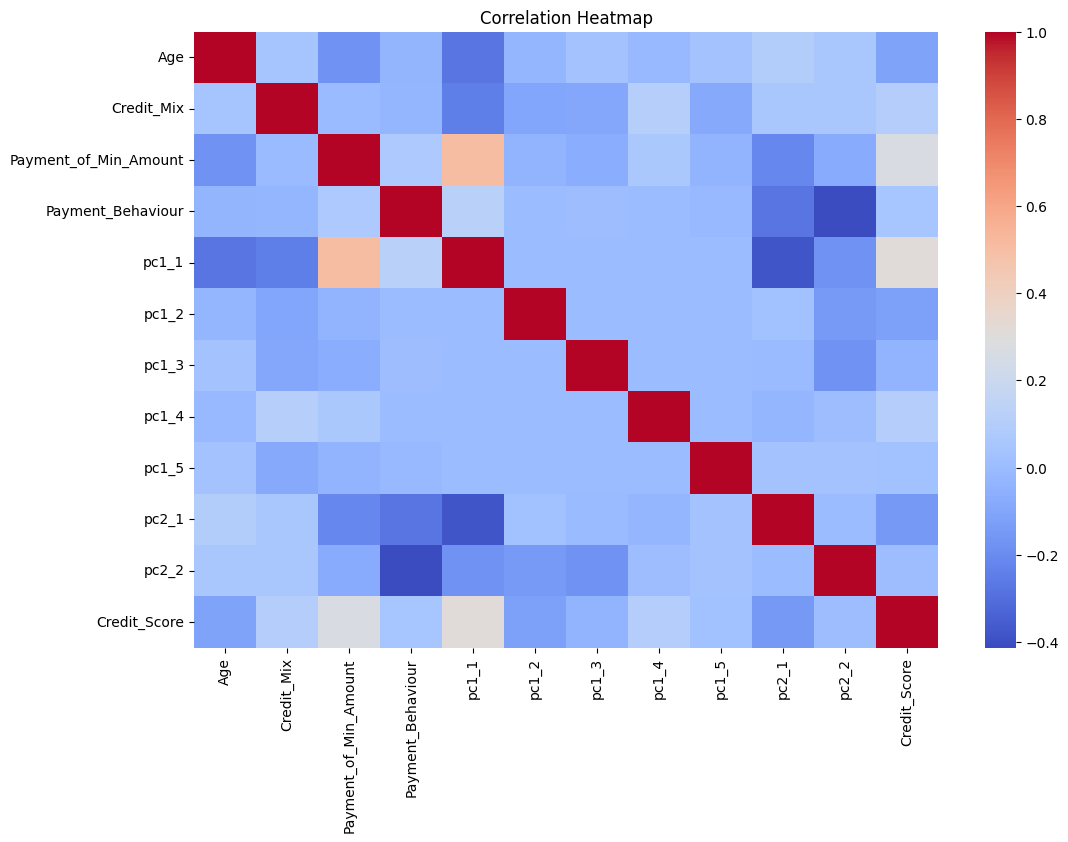

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Heatmap")
plt.show()

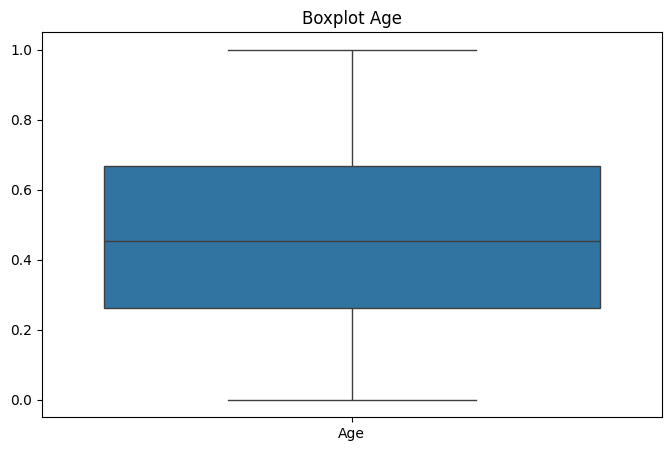

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Age']])
plt.title("Boxplot Age")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [13]:
print(df.isnull().sum().sum())

0


In [14]:
X = df.drop("Credit_Score", axis=1)
y = df["Credit_Score"]

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Shape setelah scaling:", X_scaled.shape)

Shape setelah scaling: (50808, 11)


In [16]:
df_clean = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

df_clean["Credit_Score"] = y.values

df_clean.head()

,Age,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,pc1_1,pc1_2,pc1_3,pc1_4,pc1_5,pc2_1,pc2_2,Credit_Score
0,0.859245,0.479761,0.973671,-1.497296,0.379845,1.637254,0.329180,0.290539,0.959061,-0.161756,0.350229,2
1,-1.077792,-0.510678,-0.484769,-1.497296,-0.560975,0.551029,1.331934,0.338310,0.765541,1.091791,0.895371,0
2,-0.155393,-0.510678,-0.484769,0.020917,-0.737163,0.341173,1.364082,-0.673012,1.641667,-0.784286,0.466165,0
3,0.029086,-0.510678,-1.943209,-1.497296,-0.452309,-1.160417,2.209471,-0.415694,0.083101,-0.661729,0.308175,0
4,-0.063153,-0.510678,-0.484769,1.033059,-0.883656,0.360710,1.326041,-1.727091,-0.102814,-0.776684,-0.286298,0


In [18]:
df_clean.to_csv("dataset_clean.csv", index=False)

print("Dataset berhasil disimpan")

Dataset berhasil disimpan
